In [ ]:
#P12
import numpy as np
from scipy import stats
data = [12, 15, 14, 10, 18, 20, 15, 16, 14, 13]
print("Mean:", np.mean(data))
print("Median:", np.median(data))
print("Mode:", stats.mode(data))
print("Variance:", np.var(data))
print("Standard Deviation:",np.std(data))
t_stat, p_value = stats.ttest_1samp(data, 15)
print("\nT-test:")
print("T-statistics:", t_stat)
print("P-value:", p_value)
stat, p = stats.shapiro(data)
print("\nShapiro-Wilk Test:")
print("Test statistics:", stat)
print("P-value:", p)

Mean: 14.7
Median: 14.5
Mode: ModeResult(mode=np.int64(14), count=np.int64(2))
Variance: 7.409999999999999
Standard Deviation: 2.72213151776324

T-test:
T-statistics: -0.33062326126679104
P-value: 0.7484960309136774

Shapiro-Wilk Test:
Test statistics: 0.9789133454504982
P-value: 0.959087937696012


In [ ]:
#P13
!pip install requests beautifulsoup4

In [ ]:
import requests
from bs4 import BeautifulSoup
# Define target search URL and browser-like headers
search_query = "laptops"
page_no=1
data=True
while True:
  url = f"https://www.flipkart.com/search?q={search_query}&page={page_no} "
  print(url)
  headers = {
      "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                    "AppleWebKit/537.36 (KHTML, like Gecko) "
                    "Chrome/120.0.0.0 Safari/537.36",
      "Accept-Language": "en-US,en;q=0.9"
  }
  # Send HTTP GET request
  response = requests.get(url, headers=headers)
  if response.status_code == 200:
      # Parse HTML content
      soup = BeautifulSoup(response.text, "html.parser")
      # Locate product container cards (Flipkart frequently updates these class names)
      # Target container wrapper classes for search entries
      products = soup.find_all("div", {"class": "ZFwe0M row"})
  #         print(f"Found {len(products)} items. Extracting details...\n")
      if not products:
          print("No products found on the page.")
          break
      for item in products:
          # Extract product title (handling varying tag structures safely)
          name_elem = item.find("div", {"class": "RG5Slk"}) # Scapped Product Name
          price_elem = item.find("div", {"class": "hZ3P6w DeU9vF"}) # Scapped Product Name
          discount_elem = item.find("div", {"class": "HQe8jr"})
#         print(discount_elem)
          if name_elem and discount_elem:
              print(f"Product: {name_elem.get_text(strip=True)}")
              print(f"Price:   {price_elem.get_text(strip=True)}")
              print(f"Discount:  {discount_elem.get_text(strip=True)}")
              print("-" * 40)
      print("Page no:",page_no)
  else:
      print(f"Failed to fetch page. Status code: {response.status_code}")
  page_no+=1

https://www.flipkart.com/search?q=laptops&page=1 
Product: DELL 15 AMD Ryzen 5 Quad Core 7520U - (8 GB/512 GB SSD/Windows 11 Home) DC15255 / 15 D15260 Thin and L...
Price:   ₹53,490
Discount:  18% off
----------------------------------------
Product: DELL Alienware 15 AMD Ryzen 7 260 - (16 GB/512 GB SSD/Windows 11 Home/6 GB Graphics/NVIDIA GeForce RTX...
Price:   ₹1,39,990
Discount:  16% off
----------------------------------------
Product: Acer Aspire Lite Metal (2026) AMD Ryzen 3 Quad Core 5400U - (8 GB/256 GB SSD/Windows 11 Home) AL15-41 ...
Price:   ₹36,990
Discount:  30% off
----------------------------------------
Product: HP Omnibook X Flip Next Gen AI PC Intel Core Ultra 5 226V - (16 GB/1 TB SSD/Windows 11 Home/8 GB Graph...
Price:   ₹1,19,990
Discount:  37% off
----------------------------------------
Product: Lenovo 100e Chromebook Gen 4 MediaTek Kompanio 520 - (4 GB/32 GB EMMC Storage/Chrome OS) 100e Chromebo...
Price:   ₹22,544
Discount:  13% off
---------------------------

In [ ]:
#P14
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
data = load_iris()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
#P15
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson

Binomial Distribution:
P(X = 0) = 0.0010
P(X = 1) = 0.0098
P(X = 2) = 0.0439
P(X = 3) = 0.1172
P(X = 4) = 0.2051
P(X = 5) = 0.2461
P(X = 6) = 0.2051
P(X = 7) = 0.1172
P(X = 8) = 0.0439
P(X = 9) = 0.0098
P(X = 10) = 0.0010


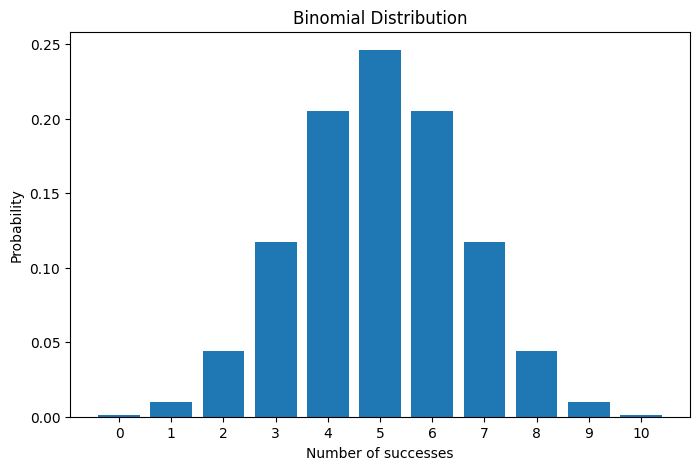

In [ ]:
n = 10
p = 0.5
x_binom = np.arange(0, n + 1)
binom_prob = binom.pmf(x_binom, n, p)
print("Binomial Distribution:")
for x, prob in zip(x_binom, binom_prob):
    print(f"P(X = {x}) = {prob:.4f}")
plt.figure(figsize=(8, 5))
plt.bar(x_binom, binom_prob)
plt.title("Binomial Distribution")
plt.xlabel("Number of successes")
plt.ylabel("Probability")
plt.xticks(x_binom)
plt.show()


Poisson Distribution:
P(X = 0) = 0.0067
P(X = 1) = 0.0337
P(X = 2) = 0.0842
P(X = 3) = 0.1404
P(X = 4) = 0.1755
P(X = 5) = 0.1755
P(X = 6) = 0.1462
P(X = 7) = 0.1044
P(X = 8) = 0.0653
P(X = 9) = 0.0363
P(X = 10) = 0.0181
P(X = 11) = 0.0082
P(X = 12) = 0.0034
P(X = 13) = 0.0013
P(X = 14) = 0.0005


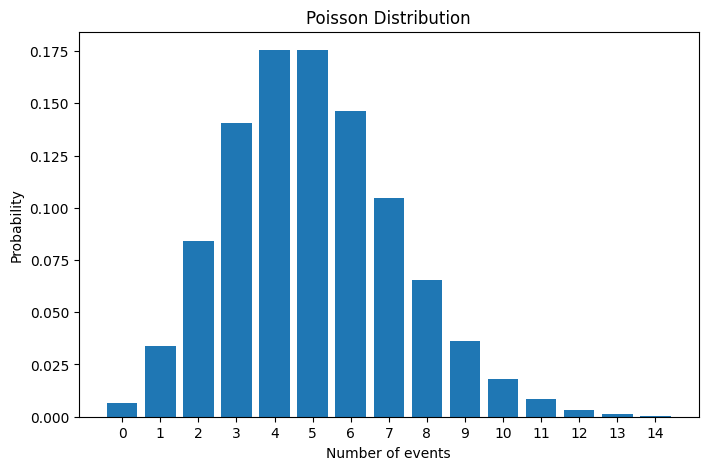

In [ ]:
lam = 5

x_poisson = np.arange(0, 15)

poisson_prob = poisson.pmf(x_poisson, lam)

print("\nPoisson Distribution:")

for x, prob in zip(x_poisson, poisson_prob):
    print(f"P(X = {x}) = {prob:.4f}")

plt.figure(figsize=(8, 5))

plt.bar(x_poisson, poisson_prob)

plt.title("Poisson Distribution")
plt.xlabel("Number of events")
plt.ylabel("Probability")
plt.xticks(x_poisson)

plt.show()

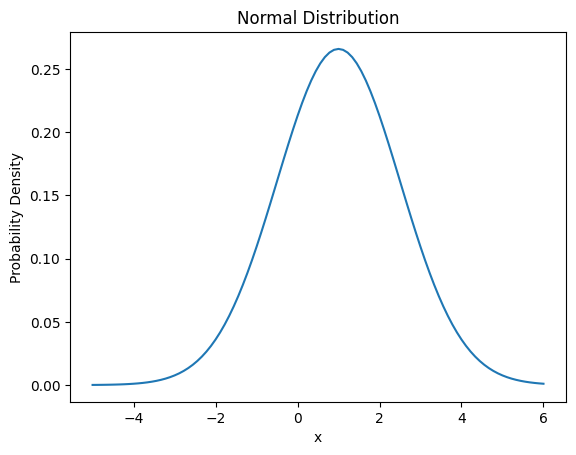

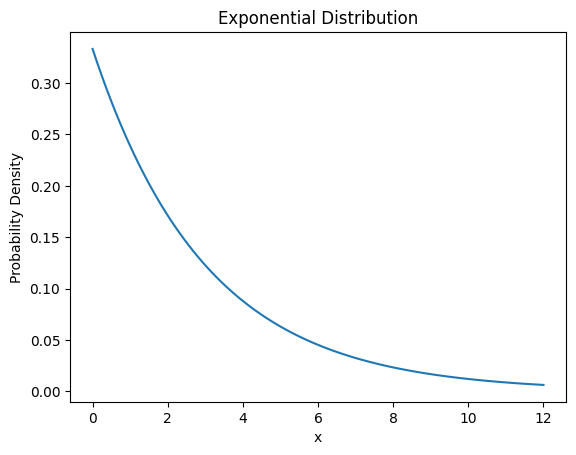

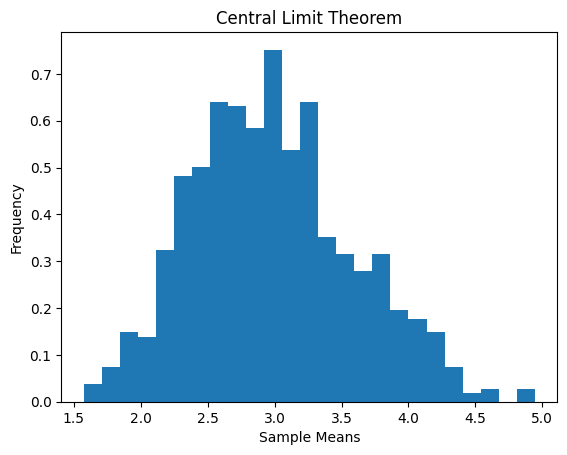

Population mean: 3.0
Mean of sample means: 2.99


In [ ]:
#P16
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, expon
# Normal distribution
mu = 1
sigma = 1.5
x = np.linspace(-5, 6, 100)
normal_pdf = norm.pdf(x, mu, sigma)
plt.plot(x, normal_pdf)
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.title("Normal Distribution")
plt.show()
# Exponential distribution
scale = 3
x = np.linspace(0, 12, 100)
exponential_pdf = expon.pdf(x, scale=scale)
plt.plot(x, exponential_pdf)
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.title("Exponential Distribution")
plt.show()
# Central Limit Theorem
population = np.random.exponential(scale=3, size=80000)
sample_means = []
for i in range(800):
    sample = np.random.choice(population, size=25)
    sample_means.append(np.mean(sample))
plt.hist(sample_means, bins=25, density=True)
plt.xlabel("Sample Means")
plt.ylabel("Frequency")
plt.title("Central Limit Theorem")
plt.show()
print("Population mean:", round(np.mean(population), 2))
print("Mean of sample means:", round(np.mean(sample_means), 2))

In [ ]:
#P17
import scipy.stats as stats
# Sample data
marks = [72, 75, 68, 80, 74, 77, 70, 73, 76, 71]
mean = 70
alpha = 0.05
t_stat, p_value = stats.ttest_1samp(marks, mean)
print("Sample data:", marks)
print("T-statistic:", round(t_stat, 2))
print("P-value:", round(p_value, 4))
if p_value < alpha:
    print("Reject the Null Hypothesis")
    print("There is a significant difference.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("There is no significant difference.")

Sample data: [72, 75, 68, 80, 74, 77, 70, 73, 76, 71]
T-statistic: 3.19
P-value: 0.011
Reject the Null Hypothesis
There is a significant difference.
